# 03 — WGAN-GP Anomaly Detector

Train a Wasserstein GAN with Gradient Penalty on **clean** (non-SAR) node embeddings.
The GAN learns what normal account embeddings look like. Accounts that can't be
reconstructed well → anomalous.

Architecture: Discriminator (critic) + Generator + Encoder

Reference: https://arxiv.org/pdf/1905.11034.pdf

In [23]:
# ── GPU Safety Cleanup — clear any leftover VRAM from previous notebooks ──
import torch, gc
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.memory_allocated()/1e6:.1f} MB allocated, {torch.cuda.memory_reserved()/1e6:.1f} MB reserved")
else:
    print("No CUDA — will use CPU")

CUDA device: NVIDIA GeForce RTX 4080 Laptop GPU
Memory: 17.5 MB allocated, 23.1 MB reserved


In [ ]:
import os
import json
import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

from gan_anomaly import (
    Discriminator, Generator, Encoder,
    gradient_penalty, anomaly_score,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Pipeline integration ──────────────────────────────────────────
_RUN_DIR = os.environ.get("AML_RUN_DIR", "")
DATA_DIR = os.path.join(_RUN_DIR, "data") if _RUN_DIR else "data"
EMBEDDINGS_DIR = os.path.join(_RUN_DIR, "embeddings") if _RUN_DIR else "embeddings"
MODELS_DIR = os.path.join(_RUN_DIR, "models") if _RUN_DIR else "models"

os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Data dir:       {os.path.abspath(DATA_DIR)}")
print(f"Embeddings dir: {os.path.abspath(EMBEDDINGS_DIR)}")
print(f"Models dir:     {os.path.abspath(MODELS_DIR)}")

## Hyperparameters

In [ ]:
LATENT_DIM = 16
D_HIDDEN = 64           # discriminator starting hidden units
G_HIDDEN = 32           # generator starting hidden units
E_HIDDEN = 64           # encoder starting hidden units
N_LAYERS = 3            # layers for each sub-network
D_STEPS = 3             # extra discriminator steps per batch
GP_WEIGHT = 10.0        # gradient penalty weight
BATCH_SIZE = 64
EPOCHS = int(os.environ.get("AML_EPOCHS", "100"))
LR_D = 0.0001
LR_G = 0.0001
LR_E = 0.0001
ACTIVATION = "leaky_relu"
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Epochs: {EPOCHS}")

## 1. Load Embeddings & SAR Labels

In [ ]:
embeddings = np.load(os.path.join(EMBEDDINGS_DIR, "node_embeddings.npy"))
node_ids = np.load(os.path.join(EMBEDDINGS_DIR, "node_ids.npy"), allow_pickle=True)
alert_nodes = pd.read_parquet(os.path.join(DATA_DIR, "alert_nodes.parquet"))

# Align SAR labels with embeddings
id_to_sar = dict(zip(alert_nodes["id"], alert_nodes["is_sar"]))
is_sar = np.array([id_to_sar.get(nid, 0) for nid in node_ids])

INPUT_DIM = embeddings.shape[1]
print(f"Embeddings: {embeddings.shape}")
print(f"Input dim:  {INPUT_DIM}")
print(f"SAR nodes:  {is_sar.sum()}")
print(f"Non-SAR:    {(is_sar == 0).sum()}")

## 2. Train / Eval Split

- **Training**: 80% of non-SAR embeddings (GAN only sees clean data)
- **Eval**: 20% non-SAR + all SAR nodes (to measure detection performance)

In [27]:
non_sar_mask = is_sar == 0
non_sar_embeddings = embeddings[non_sar_mask]
sar_embeddings = embeddings[~non_sar_mask]

X_train, X_test_nonsar = train_test_split(
    non_sar_embeddings, test_size=0.2, random_state=SEED
)

# Eval set: non-SAR test + all SAR
X_eval = np.vstack([X_test_nonsar, sar_embeddings])
y_eval = np.concatenate([np.zeros(len(X_test_nonsar)), np.ones(len(sar_embeddings))])

print(f"Training samples (non-SAR):  {len(X_train):,}")
print(f"Eval samples:               {len(X_eval):,}")
print(f"  - Non-SAR test:           {len(X_test_nonsar):,}")
print(f"  - SAR:                    {len(sar_embeddings):,}")

Training samples (non-SAR):  5,484
Eval samples:               2,016
  - Non-SAR test:           1,372
  - SAR:                    644


## 3. Create DataLoader

In [28]:
train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 85


## 4. Instantiate Models & Optimizers

In [29]:
D = Discriminator(INPUT_DIM, D_HIDDEN, N_LAYERS, ACTIVATION, dropout_rate=0.0, batch_norm=False).to(device)
G = Generator(LATENT_DIM, INPUT_DIM, G_HIDDEN, N_LAYERS, ACTIVATION, dropout_rate=0.0, batch_norm=True).to(device)
E = Encoder(INPUT_DIM, LATENT_DIM, E_HIDDEN, N_LAYERS, ACTIVATION, dropout_rate=0.0, batch_norm=True).to(device)

opt_d = torch.optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.9))
opt_g = torch.optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.9))
opt_e = torch.optim.Adam(E.parameters(), lr=LR_E, betas=(0.5, 0.9))

print("Discriminator:"); print(D)
print("\nGenerator:"); print(G)
print("\nEncoder:"); print(E)

Discriminator:
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

Generator:
Generator(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU

## 5. Training Loop

In [ ]:
history = {"d_loss": [], "g_loss": [], "e_loss": []}

for epoch in range(1, EPOCHS + 1):
    D.train(); G.train(); E.train()
    epoch_d, epoch_g, epoch_e = 0.0, 0.0, 0.0
    n_batches = 0

    for (real_data,) in train_loader:
        real_data = real_data.to(device)
        bs = real_data.size(0)

        # ---- Train Discriminator (D_STEPS times) ----
        for _ in range(D_STEPS):
            z = torch.randn(bs, LATENT_DIM, device=device)
            fake_data = G(z).detach()

            d_real = D(real_data)
            d_fake = D(fake_data)

            # Wasserstein loss
            d_loss = d_fake.mean() - d_real.mean()
            gp = gradient_penalty(D, real_data, fake_data, device)
            d_loss_total = d_loss + GP_WEIGHT * gp

            opt_d.zero_grad()
            d_loss_total.backward()
            opt_d.step()

        # ---- Train Generator ----
        z = torch.randn(bs, LATENT_DIM, device=device)
        fake_data = G(z)
        g_loss = -D(fake_data).mean()

        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

        # ---- Train Encoder ----
        z = torch.randn(bs, LATENT_DIM, device=device)
        generated = G(z)
        encoded = E(generated.detach())
        reconstructed = G(encoded)
        e_loss = torch.sum((generated.detach() - reconstructed) ** 2, dim=1).mean()

        opt_e.zero_grad()
        e_loss.backward()
        opt_e.step()

        epoch_d += d_loss_total.item()
        epoch_g += g_loss.item()
        epoch_e += e_loss.item()
        n_batches += 1

    history["d_loss"].append(epoch_d / n_batches)
    history["g_loss"].append(epoch_g / n_batches)
    history["e_loss"].append(epoch_e / n_batches)

    if epoch % 10 == 0 or epoch == 1 or EPOCHS <= 10:
        print(f"Epoch {epoch:3d}/{EPOCHS}  "
              f"D: {history['d_loss'][-1]:.4f}  "
              f"G: {history['g_loss'][-1]:.4f}  "
              f"E: {history['e_loss'][-1]:.4f}")

## 6. Training Curves

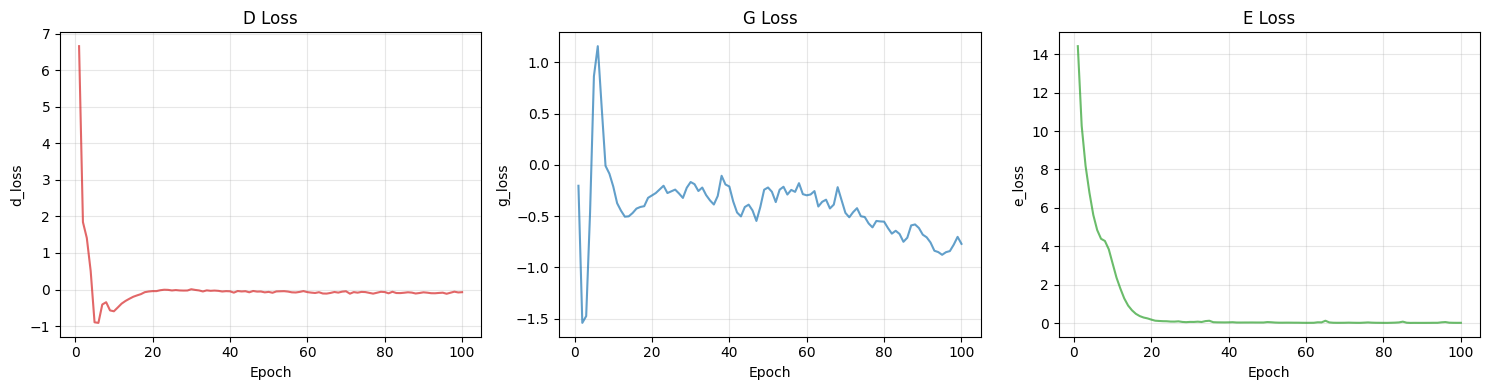

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_range = range(1, EPOCHS + 1)

for ax, key, color in zip(axes, ["d_loss", "g_loss", "e_loss"], ["tab:red", "tab:blue", "tab:green"]):
    ax.plot(epochs_range, history[key], color=color, alpha=0.7)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(key)
    ax.set_title(key.replace("_", " ").title())
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Save Models

In [ ]:
torch.save(D.state_dict(), os.path.join(MODELS_DIR, "discriminator.pt"))
torch.save(G.state_dict(), os.path.join(MODELS_DIR, "generator.pt"))
torch.save(E.state_dict(), os.path.join(MODELS_DIR, "encoder.pt"))

# Save hyperparams and training history
meta = {
    "input_dim": INPUT_DIM,
    "latent_dim": LATENT_DIM,
    "d_hidden": D_HIDDEN,
    "g_hidden": G_HIDDEN,
    "e_hidden": E_HIDDEN,
    "n_layers": N_LAYERS,
    "d_steps": D_STEPS,
    "gp_weight": GP_WEIGHT,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "activation": ACTIVATION,
}
with open(os.path.join(MODELS_DIR, "training_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

with open(os.path.join(MODELS_DIR, "training_history.json"), "w") as f:
    json.dump(history, f)

# Save train/eval splits for notebook 4
np.save(os.path.join(MODELS_DIR, "X_train.npy"), X_train)
np.save(os.path.join(MODELS_DIR, "X_eval.npy"), X_eval)
np.save(os.path.join(MODELS_DIR, "y_eval.npy"), y_eval)

print(f"Models and metadata saved to {MODELS_DIR}/")

## 8. Quick Eval — Score Distribution on Eval Set

Eval ROC AUC: 0.6528


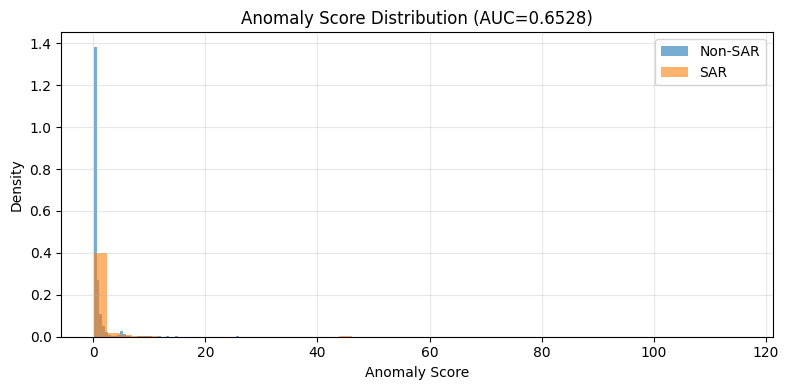

In [33]:
from sklearn.metrics import roc_auc_score

eval_tensor = torch.tensor(X_eval, dtype=torch.float32).to(device)
eval_scores = anomaly_score(eval_tensor, E, G).cpu().numpy()

auc = roc_auc_score(y_eval, eval_scores)
print(f"Eval ROC AUC: {auc:.4f}")

# Score distribution
plt.figure(figsize=(8, 4))
plt.hist(eval_scores[y_eval == 0], bins=50, alpha=0.6, label="Non-SAR", density=True)
plt.hist(eval_scores[y_eval == 1], bins=50, alpha=0.6, label="SAR", density=True)
plt.xlabel("Anomaly Score")
plt.ylabel("Density")
plt.title(f"Anomaly Score Distribution (AUC={auc:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# ── GPU Cleanup — free VRAM for next notebook ──
del D, G, E, opt_d, opt_g, opt_e, train_loader, eval_tensor
torch.cuda.empty_cache()
import gc; gc.collect()

print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e6:.1f} MB allocated, {torch.cuda.memory_reserved()/1e6:.1f} MB reserved")
print("Ready for notebook 04")

GPU memory freed: 17.5 MB allocated, 23.1 MB reserved
Ready for notebook 04
